In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Decidi Resover el laboratorio utilizando el metodo de jacobi
# 1. Parámetros y Condiciones de Frontera
nx, ny = 100, 100
phi = np.zeros((ny, nx)) # Matriz inicial para el potencial eléctrico

# Definimos el tamaño y ubicación de las placas del condensador
V0 = 100.0
placa_x1, placa_x2 = 35, 65     # Posición en el eje X
placa_y1, placa_y2 = 30, 70     # Posición y longitud en el eje Y (ancho d)

# Asignamos el voltaje constante a las placas
phi[placa_y1:placa_y2, placa_x1] = V0   # Placa izquierda (+V)
phi[placa_y1:placa_y2, placa_x2] = -V0  # Placa derecha (-V)

# Creamos una máscara booleana para que el voltaje en las placas no cambie durante la iteración
mask = np.zeros((ny, nx), dtype=bool)
mask[placa_y1:placa_y2, placa_x1] = True
mask[placa_y1:placa_y2, placa_x2] = True


# 2. Solución de la Ecuación de Laplace
# Resolvemos nabla^2(phi) = 0 iterativamente mediante el método de diferencias finitas
iteraciones = 3000
for _ in range(iteraciones):
    phi_next = np.copy(phi)
    # En diferencias finitas 2D, el valor de cada nodo es el promedio de sus 4 vecinos más cercanos
    phi_next[1:-1, 1:-1] = 0.25 * (phi[2:, 1:-1] + phi[:-2, 1:-1] +
                                   phi[1:-1, 2:] + phi[1:-1, :-2])

    # Restauramos la condición inmutable de las placas
    phi_next[mask] = phi[mask]
    phi = phi_next

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2851/1895018446.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.colorbar(label='Potencial Eléctrico $\phi$ (V)')


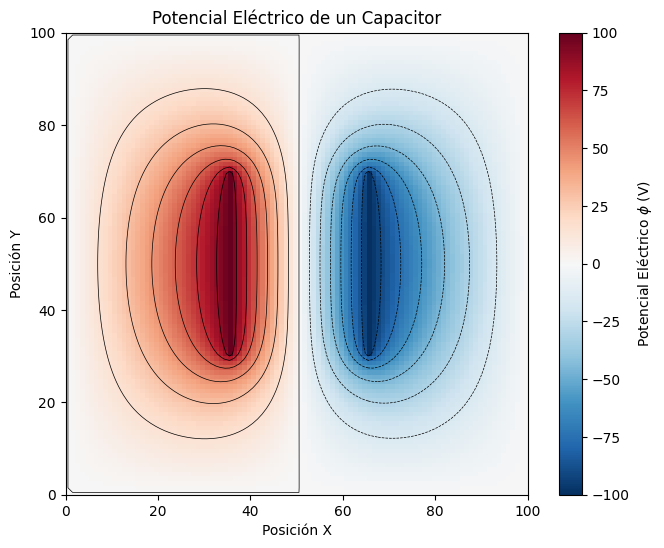

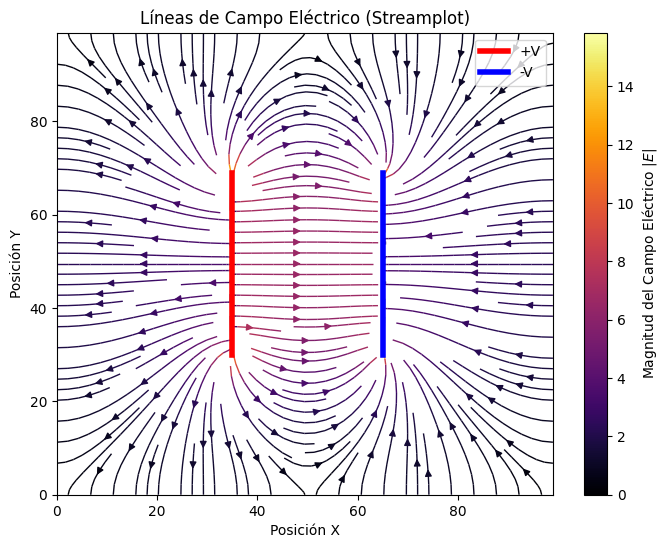

In [8]:
# 3. Visualización del Potencial

plt.figure(figsize=(8, 6))
# Se usa imshow y contour tal como se solicita en el laboratorio
plt.imshow(phi, cmap='RdBu_r', origin='lower', extent=[0, nx, 0, ny])
plt.colorbar(label='Potencial Eléctrico $\phi$ (V)')
plt.contour(phi, levels=15, colors='black', linewidths=0.5, origin='lower')
plt.title("Potencial Eléctrico de un Capacitor")
plt.xlabel("Posición X")
plt.ylabel("Posición Y")
plt.show()


# 4. Cálculo y Visualización del Campo Eléctrico
# El campo eléctrico E = -gradiente(phi). np.gradient computa internamente diferencias finitas centrales.
Ey, Ex = np.gradient(-phi)

# Preparamos las coordenadas para el gráfico vectorial
x = np.arange(0, nx)
y = np.arange(0, ny)
X, Y = np.meshgrid(x, y)

plt.figure(figsize=(8, 6))
# Se utiliza streamplot para visualizar el flujo continuo del campo vectorial (líneas de campo)
plt.streamplot(X, Y, Ex, Ey, color=np.sqrt(Ex**2 + Ey**2), cmap='inferno', density=1.5, linewidth=1)
plt.colorbar(label='Magnitud del Campo Eléctrico $|E|$')

# Dibujamos las placas para mayor claridad
plt.plot([placa_x1, placa_x1], [placa_y1, placa_y2-1], color='red', linewidth=4, label='+V')
plt.plot([placa_x2, placa_x2], [placa_y1, placa_y2-1], color='blue', linewidth=4, label='-V')

plt.title("Líneas de Campo Eléctrico (Streamplot)")
plt.xlim(0, nx-1)
plt.ylim(0, ny-1)
plt.xlabel("Posición X")
plt.ylabel("Posición Y")
plt.legend(loc='upper right')
